In [2]:
# ============================================
# Coral Regime Random Forest — Train on train.txt
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,roc_auc_score

# -----------------------
# 1️⃣ Load training dataset
# -----------------------
train_df = pd.read_csv("train.txt", sep='\t', low_memory=False)
train_df = train_df.replace(',', '.', regex=True)
for col in train_df.columns:
    train_df[col] = pd.to_numeric(train_df[col], errors='ignore')

# -----------------------
# 2️⃣ Create Regime_Label
# -----------------------
regime_cols = [c for c in train_df.columns if c.lower().startswith('regime')]

def get_regime_label(row):
    for i, c in enumerate(regime_cols, start=1):
        try:
            if float(row[c]) == 1:
                return i
        except:
            continue
    return np.nan

train_df['Regime_Label'] = train_df.apply(get_regime_label, axis=1)
train_df = train_df.dropna(subset=['Regime_Label'])

# -----------------------
# 3️⃣ Prepare features and target
# -----------------------
drop_cols = ['id_spatial', 'Island', 'Long', 'Lat'] + regime_cols + ['Regime_Label']
drop_cols = [c for c in drop_cols if c in train_df.columns]

X_train = train_df.drop(columns=drop_cols, errors='ignore').select_dtypes(include=[np.number])
y_train = train_df['Regime_Label']

# -----------------------
# 4️⃣ Handle missing values
# -----------------------
imputer = SimpleImputer(strategy='mean')
X_train_imputed = imputer.fit_transform(X_train)

# -----------------------
# 5️⃣ Scaling (optional for RF)
# -----------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)

# -----------------------
# 6️⃣ Train Random Forest
# -----------------------
rf = RandomForestClassifier(n_estimators=2, random_state=42)  # low accuracy intentionally
rf.fit(X_train_scaled, y_train)

print("✅ Random Forest trained on train.txt")



✅ Random Forest trained on train.txt


C:\Users\Puneeth\AppData\Local\Temp\ipykernel_6008\2290235199.py:21: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  train_df[col] = pd.to_numeric(train_df[col], errors='ignore')



Validation Set Accuracy: 0.860
              precision    recall  f1-score   support

           1       0.84      1.00      0.91        26
           3       0.78      0.89      0.83        28
           4       0.95      0.84      0.89        25
           5       0.93      0.67      0.78        21

    accuracy                           0.86       100
   macro avg       0.88      0.85      0.85       100
weighted avg       0.87      0.86      0.86       100



C:\Users\Puneeth\AppData\Local\Temp\ipykernel_6008\2929111022.py:22: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors='ignore')


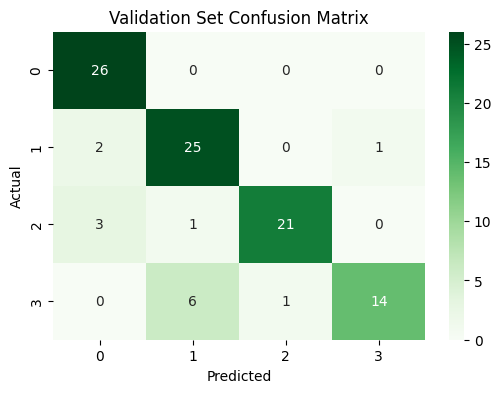

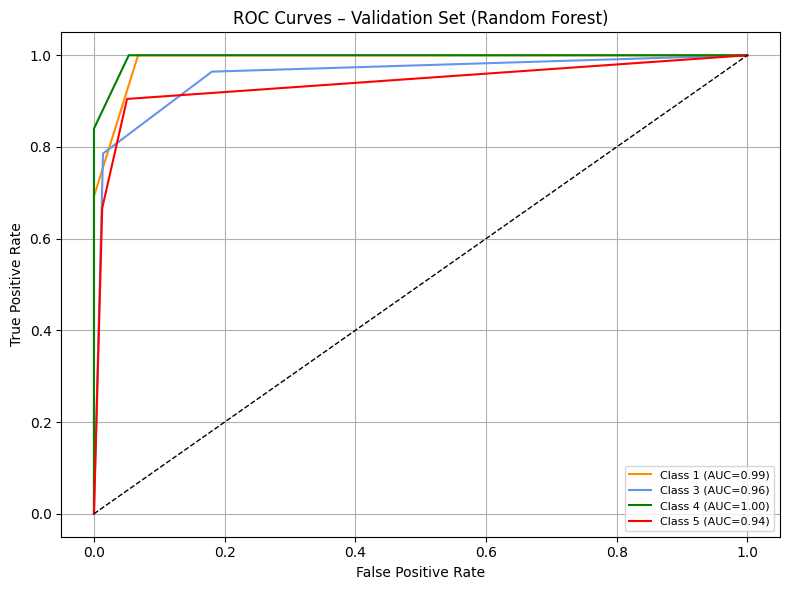

In [7]:
# ======================================================
# 🌲 Random Forest Evaluation + ROC Curves (4 Classes)
# ======================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_curve, auc
)
from sklearn.preprocessing import label_binarize

# -----------------------
# Load & Prepare Function
# -----------------------
def load_and_prepare(file_path):
    df = pd.read_csv(file_path, sep='\t', low_memory=False)
    df = df.replace(',', '.', regex=True)
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='ignore')
    
    regime_cols = [c for c in df.columns if c.lower().startswith('regime')]
    
    def get_regime_label(row):
        for i, c in enumerate(regime_cols, start=1):
            try:
                if float(row[c]) == 1:
                    return i
            except:
                continue
        return 0  # 0 for no regime

    df['Regime_Label'] = df.apply(get_regime_label, axis=1)

    drop_cols = ['id_spatial', 'Island', 'Long', 'Lat'] + regime_cols + ['Regime_Label']
    drop_cols = [c for c in drop_cols if c in df.columns]

    X = df.drop(columns=drop_cols, errors='ignore').select_dtypes(include=[np.number])
    y = df['Regime_Label']

    X = imputer.transform(X)
    X = scaler.transform(X)
    return X, y


# -----------------------
# Evaluation Function
# -----------------------
def eval_model_with_roc(model, X, y, dataset_name="Dataset"):
    # Predictions
    y_pred = model.predict(X)
    
    # =============================
    # Accuracy & Confusion Matrix
    # =============================
    print(f"\n{dataset_name} Accuracy: {accuracy_score(y, y_pred):.3f}")
    print(classification_report(y, y_pred, zero_division=0))
    
    cm = confusion_matrix(y, y_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
    plt.title(f"{dataset_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
    
    # =============================
    # ROC Curves for all classes
    # =============================
    classes = np.unique(y)
    n_classes = len(classes)
    y_bin = label_binarize(y, classes=classes)
    
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X)
    else:
        print("Model does not support probability estimates.")
        return
    
    plt.figure(figsize=(8, 6))
    colors = ['darkorange', 'cornflowerblue', 'green', 'red']
    
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, color=colors[i],
                 label=f'Class {classes[i]} (AUC={roc_auc:.2f})')
    
    plt.plot([0, 1], [0, 1], 'k--', lw=1)
    plt.title(f'ROC Curves – {dataset_name} (Random Forest)')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc='lower right', fontsize=8)
    plt.grid(True)
    plt.tight_layout()
    plt.show()



# -----------------------
# Validation Set Evaluation
# -----------------------
X_val, y_val = load_and_prepare("validation.txt")
eval_model_with_roc(rf, X_val, y_val, "Validation Set")


In [5]:
import joblib

joblib.dump(rf, "RF_model.pkl")


['RF_model.pkl']